## *Crop yield forecasting:

### A detailed analysis on the yield of crop in India for an year.

### #Importing all the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### #Loading the Data

In [2]:
data = pd.read_csv("crop_yield.csv")
data.head(10)

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909
5,Dry chillies,1997,Whole Year,Assam,13587.0,9073,2051.4,1293074.79,4211.97,0.643636
6,Gram,1997,Rabi,Assam,2979.0,1507,2051.4,283511.43,923.49,0.465455
7,Jute,1997,Kharif,Assam,94520.0,904095,2051.4,8995468.40,29301.20,9.919565
8,Linseed,1997,Rabi,Assam,10098.0,5158,2051.4,961026.66,3130.38,0.461364
9,Maize,1997,Kharif,Assam,19216.0,14721,2051.4,1828786.72,5956.96,0.615652


### #Exploratory Data Analysis

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB


In [4]:
data.columns.values

array(['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production',
       'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield'],
      dtype=object)

In [5]:
data.shape

(19689, 10)

In [6]:
data["Season"].unique()

array(['Whole Year ', 'Kharif     ', 'Rabi       ', 'Autumn     ',
       'Summer     ', 'Winter     '], dtype=object)

In [7]:
data["Season"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 19689 entries, 0 to 19688
Series name: Season
Non-Null Count  Dtype 
--------------  ----- 
19689 non-null  object
dtypes: object(1)
memory usage: 153.9+ KB


### #Preprocessing

In [8]:
# Input Features
x = data[['Annual_Rainfall', 'Area', 'Fertilizer', 'Production']]

# Target Variable
y = data['Yield']

### #Training

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [10]:
len(x_train)

15751

In [11]:
x_train

,Annual_Rainfall,Area,Fertilizer,Production
19466,3340.395455,357.0,59804.64,1022
17802,677.500000,75.0,10005.00,196
7014,883.400000,204.0,21650.52,84
14078,1287.400000,21054.0,3178311.84,24800
8121,800.800000,552393.0,52295045.31,379455
...,...,...,...,...
11284,585.800000,24695.0,3847974.90,61514
11964,1096.000000,17229.0,2861909.19,84356
5390,970.900000,16518.0,2600593.92,153558
860,1002.900000,21799.0,2226331.87,16137


In [12]:
len(x_test)

3938

In [13]:
x_test

,Annual_Rainfall,Area,Fertilizer,Production
18238,902.8,210.00,3.218250e+04,1010
6918,1484.3,8270.00,8.776951e+05,10280
4894,3837.1,6341.00,9.717582e+05,44026
10960,1295.2,29768.73,4.258119e+06,27189
15615,800.0,8950.00,1.409088e+06,4970
...,...,...,...,...
8087,860.8,114975.00,1.088468e+07,535821
14720,1717.0,25.00,3.947750e+03,9
9234,1612.9,46467.00,5.034235e+06,71469
19610,1460.5,32617.00,4.998555e+06,23981


### #Model Selection

In [14]:
rf_model = RandomForestRegressor(n_estimators=100,max_depth=10,random_state=42)

In [15]:
rf_model.fit(x_train,y_train)

RandomForestRegressor(max_depth=10, random_state=42)

In [16]:
y_pred = rf_model.predict(x_test)

### #Model Accuracy

In [17]:
r2 = r2_score(y_test,y_pred)

In [18]:
r2

0.9060214965198368

### #Visualization

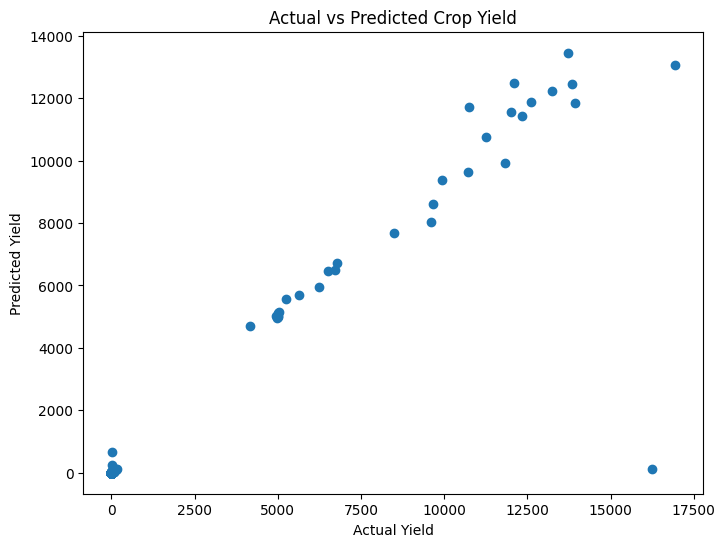

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")

plt.title("Actual vs Predicted Crop Yield")

plt.show()

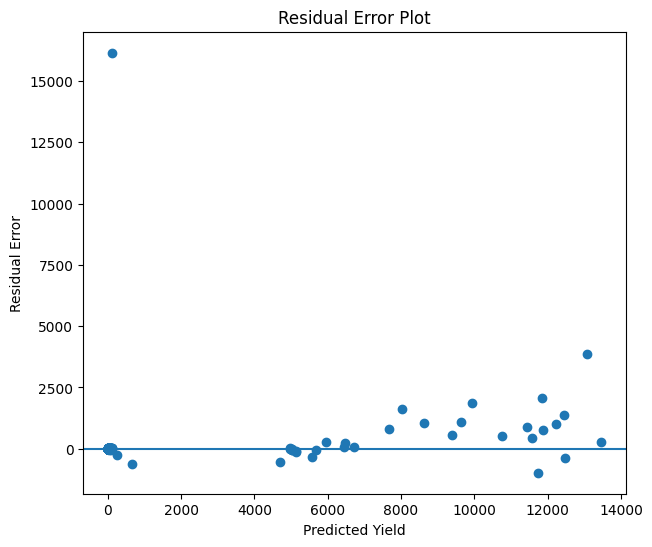

In [20]:
errors = y_test - y_pred

plt.figure(figsize=(7,6))

plt.scatter(y_pred, errors)

plt.axhline(y=0)

plt.xlabel("Predicted Yield")
plt.ylabel("Residual Error")

plt.title("Residual Error Plot")

plt.show()